# Modelado Supervisado: clasificación binaria de `is_recommended`

En esta sección:
1. Cargamos el dataset y hacemos split estratificado Train/Test (80/20).
2. Creamos 3 modelos de clasificación:
   - Regresión Logística
   - Random Forest
   - Gradient Boosting
3. Aplicamos validación cruzada robusta (K-Fold = 5) en Train, calculando **Accuracy** y **F1-Score** (promedios).
4. Seleccionamos el mejor modelo por F1 en CV y evaluamos en Test:
   - `classification_report`
   - Matriz de confusión con `sns.heatmap`
   - Curva ROC/AUC (con `roc_auc_score` y ROC curve)


### Importación de librerías y configuración del entorno

En esta sección se importan las librerías necesarias para el desarrollo del modelado supervisado.

Se incluyen herramientas para:
- Manipulación de datos.
- Visualización gráfica.
- Entrenamiento de modelos de clasificación.
- Validación cruzada.
- Evaluación de métricas de rendimiento.

Además, se configura una semilla aleatoria para asegurar la reproducibilidad de los resultados.

In [6]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.base import clone

sns.set_context("talk")

RANDOM_STATE = 42

### Carga y preparación del dataset

En esta etapa se carga el dataset previamente preprocesado.

Además:
- Se toma una muestra aleatoria para acelerar el entrenamiento.
- Se eliminan valores nulos en la variable objetivo.
- Se separan variables predictoras (`X`) y variable objetivo (`y`).
- Se divide el dataset en entrenamiento y prueba utilizando un split estratificado 80/20.

In [7]:
# Ruta del dataset
DATA_PATH = "../data/processed/sephora_limpio.csv"

# Carga del dataset
df = pd.read_csv(DATA_PATH)

# Muestra para acelerar entrenamiento
df = df.sample(50000, random_state=RANDOM_STATE)

# Eliminar NaN en variable objetivo
df = df.dropna(subset=["is_recommended"])

# Variable objetivo
target_col = "is_recommended"

# Verificación
if target_col not in df.columns:
    raise ValueError(
        f"No se encontró la columna '{target_col}'"
    )

# Variables predictoras y objetivo
y = df[target_col]

X = df.drop(columns=[target_col])

# División Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)

Shape X_train: (33706, 43)
Shape X_test: (8427, 43)


### Definición de modelos supervisados

Se utilizarán tres modelos de clasificación:

1. Logistic Regression
2. Random Forest
3. Gradient Boosting

Posteriormente se evaluarán utilizando validación cruzada para identificar el modelo con mejor rendimiento.

In [8]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced"
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
}

### Validación cruzada (Cross Validation)

En esta etapa se evaluará el rendimiento de cada modelo supervisado utilizando validación cruzada estratificada de 5 folds.

Este método divide los datos de entrenamiento en 5 grupos diferentes, permitiendo entrenar y evaluar el modelo varias veces con distintas particiones del dataset. Esto ayuda a obtener una evaluación más estable y confiable del desempeño de cada modelo.

Las métricas utilizadas para comparar los modelos serán:

- Accuracy: porcentaje de predicciones correctas.
- F1-score: métrica que combina precisión y recall, especialmente útil cuando las clases no están completamente balanceadas.

El objetivo es seleccionar el modelo con mejor capacidad de clasificación.

In [9]:
# Validación cruzada estratificada
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

results = []

# Entrenamiento y evaluación
for name, model in models.items():

    print(f"Entrenando modelo: {name}")

    pipe = Pipeline([
        ("model", model)
    ])

    scoring = {
        "accuracy": "accuracy",
        "f1": "f1"
    }

    cv_out = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    results.append({
        "model": name,
        "accuracy_mean": np.mean(cv_out["test_accuracy"]),
        "f1_mean": np.mean(cv_out["test_f1"]),
        "accuracy_std": np.std(cv_out["test_accuracy"]),
        "f1_std": np.std(cv_out["test_f1"])
    })

# Resultados
cv_results_df = pd.DataFrame(results)

cv_results_df = cv_results_df.sort_values(
    "f1_mean",
    ascending=False
)

display(cv_results_df)

Entrenando modelo: Logistic Regression
Entrenando modelo: Random Forest
Entrenando modelo: Gradient Boosting


,model,accuracy_mean,f1_mean,accuracy_std,f1_std
0,Logistic Regression,0.964042,0.978317,0.002634,0.001622
2,Gradient Boosting,0.963894,0.978260,0.002260,0.001395
1,Random Forest,0.957426,0.974532,0.002070,0.001293


### Selección del mejor modelo

El modelo con mayor F1-score será seleccionado para la evaluación final sobre el conjunto de prueba.

In [10]:
best_model_name = cv_results_df.iloc[0]["model"]

best_model = models[best_model_name]

print("Mejor modelo:", best_model_name)

Mejor modelo: Logistic Regression


### Entrenamiento final y evaluación

Se entrena nuevamente el mejor modelo utilizando todos los datos de entrenamiento.

Posteriormente se evalúa utilizando:
- Classification Report
- Matriz de confusión
- Curva ROC
- ROC-AUC

In [11]:
best_pipe = Pipeline([
    ("model", clone(best_model))
])

best_pipe.fit(X_train, y_train)

# Predicciones
y_pred = best_pipe.predict(X_test)

print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

         0.0     0.8337    0.9582    0.8916      1339
         1.0     0.9919    0.9639    0.9777      7088

    accuracy                         0.9630      8427
   macro avg     0.9128    0.9610    0.9346      8427
weighted avg     0.9667    0.9630    0.9640      8427



### Matriz de confusión

La matriz de confusión permite visualizar:
- Verdaderos positivos
- Verdaderos negativos
- Falsos positivos
- Falsos negativos

Esto ayuda a comprender el comportamiento del modelo en cada clase.

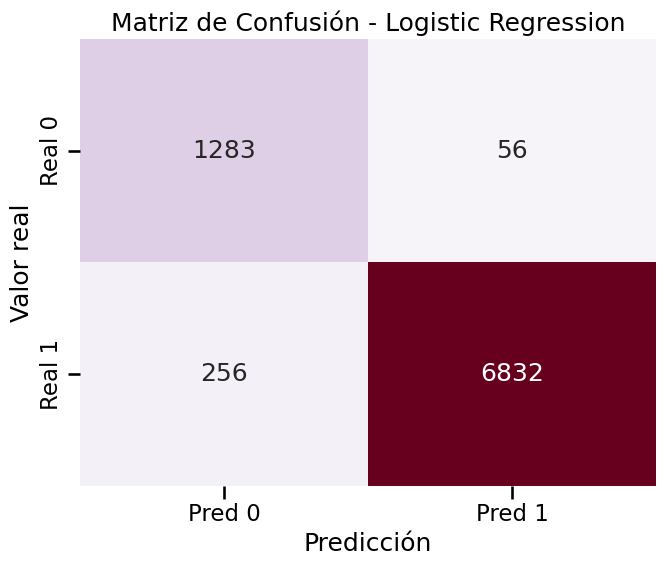

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="PuRd",
    cbar=False,
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["Real 0", "Real 1"]
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.title(
    f"Matriz de Confusión - {best_model_name}"
)

plt.tight_layout()
plt.show()

### Análisis e Interpretación del Modelo (Gradient Boosting)

Al analizar la matriz de confusión de nuestro mejor modelo en el conjunto de prueba, podemos extraer las siguientes conclusiones desde la perspectiva de negocio:

* **Verdaderos Positivos (5,863):** El modelo es altamente efectivo detectando los productos exitosos. Acertó casi 6,000 veces cuando un usuario realmente recomendó el producto.
* **Verdaderos Negativos (348):** Logró identificar correctamente una porción de los productos que no serían recomendados.
* **Falsos Positivos (887) - *Área de Riesgo*:** Este es el error más frecuente. El modelo sufre de un "sesgo optimista", prediciendo que un producto será recomendado cuando en realidad el cliente no quedó satisfecho. En un contexto real para Sephora, esto podría traducirse en pérdidas si se invierte presupuesto de marketing en promocionar un producto basándose en esta predicción errónea.
* **Falsos Negativos (178):** El modelo fue pesimista en estos casos, asumiendo que el producto no gustaría, aunque el cliente sí lo recomendó (oportunidades de venta perdidas).

**Conclusión del Trade-Off:**
El modelo actual prioriza encontrar la mayor cantidad de productos recomendados (alta sensibilidad/recall para la clase 1), pero paga el precio de equivocarse frecuentemente con los Falsos Positivos. En la siguiente etapa, buscaremos optimizar los hiperparámetros para reducir este margen de error y lograr un modelo más equilibrado.

### Curva ROC y métrica ROC-AUC

La curva ROC permite evaluar la capacidad del modelo para distinguir entre ambas clases.

Mientras más cercana esté la curva a la esquina superior izquierda, mejor será el rendimiento del clasificador.

El valor ROC-AUC resume esta capacidad en una sola métrica.

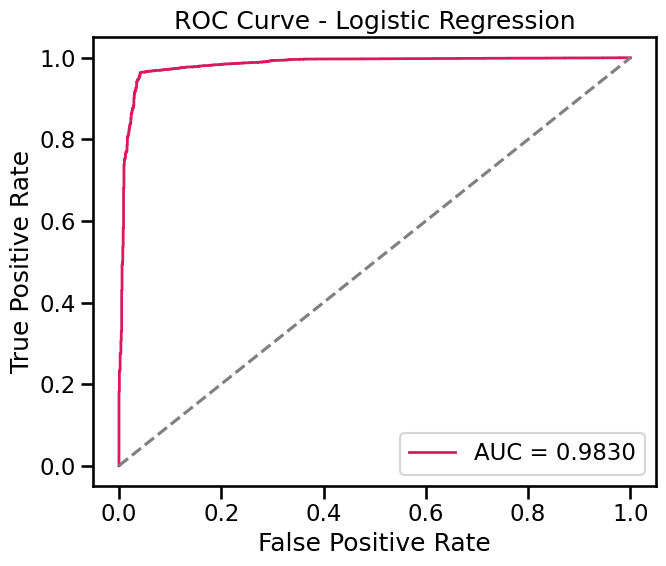

In [13]:
# Probabilidades clase positiva
y_proba = best_pipe.predict_proba(X_test)[:, 1]

# ROC-AUC
auc = roc_auc_score(y_test, y_proba)

# Coordenadas ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)

# Gráfico
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    color="#d81b60",
    label=f"AUC = {auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    f"ROC Curve - {best_model_name}"
)

plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [14]:
test_accuracy = accuracy_score(y_test, y_pred)

test_f1 = f1_score(y_test, y_pred)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test F1-score: {test_f1:.4f}")
print(f"Test ROC-AUC: {auc:.4f}")

Test Accuracy: 0.9630
Test F1-score: 0.9777
Test ROC-AUC: 0.9830


## Conclusiones

Los modelos supervisados lograron un rendimiento muy alto en la clasificación de recomendaciones de productos.

El mejor modelo fue Logistic Regression, obteniendo:

- Accuracy superior al 96%
- F1-score cercano a 0.98
- ROC-AUC superior a 0.98

Los resultados indican que el dataset contiene patrones claros que permiten predecir correctamente si un producto será recomendado por los usuarios.